<a href="https://colab.research.google.com/github/javiermagnone-lab/Javito/blob/main/Taller_obligatorio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Obligatorio 1**
**- Integrantes:** Valentina Corroti - Guzman Momplet - Javier Magnone
______________________________

**- Repositorio:** https://github.com/javiermagnone-lab/Javito/blob/main/Taller_obligatorio_1.ipynb

**- Diagrama de trabajo**
|#| Sección | Estado|
|---|---|---|
|00| Importarción de librerias y dataset | Finalizado|
|01| Entendimiento del dataset| ¿Finalizado?|
|02| Auditoria de calidad de los datos | Comenzado|
|03| Agrupación por order_id y evaluación de calidad por order_id| Comenzado|
|04| Analisis Univariado | No comenzado|
|05| Analisis Bivariado| No comenzado|



## **00. Importar librerías y carga del dataset**

In [5]:
#Librerías

import pandas as pd
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
!pip install gdown

In [3]:
import gdown

In [6]:
# Carga del dataset
file_id = '1pXy-PVoAIEx4NxqVqtzGhSmI7tupIVHK'

# Descargar el archivo parquet
gdown.download(f'https://drive.google.com/uc?id={file_id}',
               'archivo.parquet', quiet=False)

df = pd.read_parquet('archivo.parquet')

Downloading...
From (original): https://drive.google.com/uc?id=1pXy-PVoAIEx4NxqVqtzGhSmI7tupIVHK
From (redirected): https://drive.google.com/uc?id=1pXy-PVoAIEx4NxqVqtzGhSmI7tupIVHK&confirm=t&uuid=c80d9825-9125-49b5-bd25-e87445784d7f
To: /content/archivo.parquet
100%|██████████| 2.27G/2.27G [00:14<00:00, 156MB/s]


# **01. Entendimiento del dataset**

### *Resumen*

|Tarea | Código | Estado|
|---|---|---|
| Información general | df.info()| Listo
| Lectura del dataset | df.head() | Listo
| Forma del dataset | df.shape| Listo
| Nombres de columnas | df.columns.values.tolist() | Listo
| Tipo de columnas| str(df[col].dtype | Listo
| Total valores por columna | df[col].count()| Listo
| # de nulos en columnas| df[col].isnull().sum()| Listo
| % de nulos en columnas| round(df[col].isnull().mean() * 100, 2)| Listo
| valor mas frecuente en columna| str(top_val) | Listo
| % del valor mas frecuente en columna | top_pct| Listo
| muestra de la columna| df[col].dropna().unique()[:3].tolist()| Listo



In [7]:
# Información general

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15551102 entries, 0 to 15551101
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   order_id            object 
 1   product_id          object 
 2   category            object 
 3   weekday             object 
 4   hour                Int64  
 5   business_type_name  object 
 6   partner_id          object 
 7   user_id             object 
 8   qty_total_products  Int64  
 9   total_amount        float64
 10  has_discount        boolean
 11  is_food             boolean
 12  hist_qc_orders      Int64  
dtypes: Int64(3), boolean(2), float64(1), object(7)
memory usage: 1.4+ GB


In [8]:
#Lectura del dataset

df.head()

,order_id,product_id,category,weekday,hour,business_type_name,partner_id,user_id,qty_total_products,total_amount,has_discount,is_food,hist_qc_orders
0,PpTjCz6Rpezd61n5dPDJTuRqdeuei9ZF179usLRlHDo=,3PhxU90RAhdnzFLvK754zH8dCyaGhx+gRZK6FejN72c=,snacks,Wednesday,2,Kiosks,wGj5g/FyaoIGakOjc8rsSMKLP4ObLso+ToeBLz5gYXA=,MK8B+8oYcJV/UOWHXwSRZKONfUd4BeOoYDlqDfsf6G8=,4,29.047982,True,True,3857
1,b2fkJT7l609B1C5C4mOPpEGmJN9kFsFBEMfA1CFcg+Q=,nW7qzj8ZjWDhm9APVZBpQK+PZ5Rt8kpiJCw9OZ46FPA=,verduras,Wednesday,6,Market,boCBw+WzpRefsURSsXYnYGpr1HAK4RBUHV8hCmvGxGE=,xL2+iPNakXvX1le6s/sXR6QoP2FF44ZYziBWF9wvUNU=,32,185.701304,True,True,871
2,aRM17cbzgUQM2gYrzeKgZF5iPWe+4BoxGZzUR4I9u9M=,EA22Jy/uYTzJrbJZE0v70PUSzzUqzcP9vfWOVOctuJk=,quesos,Friday,7,Market,CSq+DtmiVKcNLprPiiWNTgH5sg97DimLHyswaz3tA5M=,Tk6M9oGhf9s7nUS0Lgf/cYArZLjpsFUnbQzFsQJB2Fc=,39,161.954034,True,True,198
3,ofBqN0N2C1oa7TclCSCS5PTJKTF4DWZJUA85gymH2rY=,P8NwM7gXFCIAeDJdyTCA2+LfcpTOFTi59ASuO7nmymg=,huevos,Friday,7,Market,CSq+DtmiVKcNLprPiiWNTgH5sg97DimLHyswaz3tA5M=,SJ9SEqbIILAEiKPrZ1+18MvW76IDBljdaYCT18wSjWA=,11,32.065813,True,True,246
4,0/7FYlHaqnXz2vaadJWARDRCjxDNRTgguABQXg/mlXc=,9nHMU4b5PPyfTH73olgbjZtx6hvcNtpZFSs1eXUJWb4=,productos de limpieza,Friday,7,Market,T4q47JhNP6vNeE2q/TgmqAJ+QQ1ryCWfr+virSVP8JA=,gI3OKl4ZOAL9N6+RsNfSxwx0oW4Ho3W3jO/KMt9pkqE=,11,25.598921,True,True,233


In [9]:
# Forma del dataset

df.shape

(15551102, 13)

In [10]:
#Lista a las columnas

columns = df.columns.values.tolist()
print(columns)

['order_id', 'product_id', 'category', 'weekday', 'hour', 'business_type_name', 'partner_id', 'user_id', 'qty_total_products', 'total_amount', 'has_discount', 'is_food', 'hist_qc_orders']


In [11]:
# Tabla con descripción general de las columnas

resumen = []
for col in df.columns:
    top_val = df[col].value_counts().idxmax() if df[col].count() > 0 else None
    top_pct = round(df[col].value_counts(normalize=True).max() * 100, 2) if df[col].count() > 0 else None

    resumen.append({
        'columna':             col,
        'tipo':                str(df[col].dtype),
        'total_valores':       df[col].count(),
        'valores_unicos':      df[col].nunique(),
        'nulos':               df[col].isnull().sum(),
        '% nulos':             round(df[col].isnull().mean() * 100, 2),
        'valor_mas_frecuente': str(top_val),
        '% mas_frecuente':     top_pct,
        'muestra':             str(df[col].dropna().unique()[:3].tolist())
    })

resumen_df = pd.DataFrame(resumen).set_index('columna')
resumen_df_original = resumen_df.copy()  # copia fija con nulos para exportar
resumen_df

,tipo,total_valores,valores_unicos,nulos,% nulos,valor_mas_frecuente,% mas_frecuente,muestra
columna,,,,,,,,
order_id,object,15092415,2474292,458687,2.95,cgocQnyCn9TodZwpf/pJyLgcFUkI+pBHWEoOKnAf72s=,0.00,['PpTjCz6Rpezd61n5dPDJTuRqdeuei9ZF179usLRlHDo=...
product_id,object,15551102,1545189,0,0.00,zMD29MXup2v/rYSi9yVqf2/hDUO+O2rmBPbfYrMR8bA=,0.03,['3PhxU90RAhdnzFLvK754zH8dCyaGhx+gRZK6FejN72c=...
category,object,15551102,62,0,0.00,pagnificados,7.57,"['snacks', 'verduras', 'quesos']"
weekday,object,15092415,7,458687,2.95,Sunday,17.78,"['Wednesday', 'Friday', 'Saturday']"
hour,Int64,15092415,24,458687,2.95,19,11.73,"[2, 6, 7]"
business_type_name,object,15092415,3,458687,2.95,Market,94.95,"['Kiosks', 'Market', 'Shop']"
partner_id,object,15092415,2261,458687,2.95,CSq+DtmiVKcNLprPiiWNTgH5sg97DimLHyswaz3tA5M=,2.07,['wGj5g/FyaoIGakOjc8rsSMKLP4ObLso+ToeBLz5gYXA=...
user_id,object,15092415,652879,458687,2.95,l7sBloJsG8eqTemjZSo29Fp6rhirzbKCoy3+hBzUCc4=,0.01,['MK8B+8oYcJV/UOWHXwSRZKONfUd4BeOoYDlqDfsf6G8=...
qty_total_products,Int64,15092415,176,458687,2.95,11,6.13,"[4, 32, 39]"


## **02. Auditoría de calidad de datos**

## *Resumen*
___
General
|Tarea|Utilidad|Estado|
|---|---|---|
| Analizo columnas con nulos según fila | ¿Hay datos faltantes? | Listo|
| Eliminación de filas con nulos | Acción |Listo|
| Busco filas con todas sus columnas iguales | ¿cada registro es unico? |Listo|
| Busco duplicados de order_id + product_id| ¿Las ordenes tienen productos duplicados?|Listo|
| Mapeo de IDs | Facilidad de lectura| Listo
 _____________

Variables cuantitativas
|Tarea|Utilidad|Estado|
|---|---|---
| Impresión de estadisticas básicas | Variables cuantitativas | Listo|
| Boxplot de cuantitativas | Primera visualización | Listo|
| Total_amount = 0 | ¿ Cuantos datos son = $0 ? | Listo|
| Total_amount = 0 | Como se distribuyen según cantidad de productos| Listo|
| Total_amount = 0 | ¿Son ordenes con descuentos? | Listo|
| Total_amount - qty_quantity: Valores muy altos | Selecciono el p99 para analizar mejor | Listo
| Total_amount - qty_quantity: son coherentes los maximos?| Top 10 maximos | Listo|
| Total_amount - qty_quantity: son coherentes los maximos?| Grafico | Listo|
|Total_amount - qty_quantity: Analizo los 4 valores anomalos detectados| ¿presentan algo en común según cats?| Listo
|hist_qc_orders = 19,999 — posible valor de tope artificial?| Analizó cuantos 19.999 hay| Listo
_____________________
Variables categoricas
|Tarea|Utilidad|Estado|
|---|---|---|
|businees_type_name| **Falta**| Falta|
| Category: descripción | Analizo valores unicos: se repiten, idioma, sin datos? | Listo
|Category: comportamiento | Categoria sin valor, ¿como se comporta?| Listo
|Categoy: comportamiento | Cambio dairy (lacteos) y vacios por "Sin Categoria"| Listo
________________________
Variables temporales
|Tarea|Utilidad|Estado|
|---|---|---|
|hour y weekend: cobertura| ¿representan todo el intervalo temporal?|Listo
________________________
Variables booleanas
|Tarea|Utilidad|Estado|
|---|---|---|
|is_food| Falta| Falta|
|has_discount| Falta|Falta|
________________________
Variables IDs
|Tarea|Utilidad|Estado|
|---|---|---|
|User_id| Falta| Falta|
|Product_id| Falta|Falta|
|Partner_id| Falta|Falta|
















In [12]:
# Evaluo si los nulos son filas completas

nulos_por_fila = df.isnull().sum(axis=1)
dist = nulos_por_fila.value_counts().sort_index()

print("" * 45)
print(f"{'Columnas nulas por fila':<25} {'Cantidad de filas':>18}")
print("" * 45)
for n, cant in dist.items():
    pct = cant / len(df) * 100
    print(f"  {n:>2} columnas nulas {'':>10} {cant:>10,}  ({pct:.1f}%)")
print("" * 45)
print(f"\n✓ Solo existen filas con 0 ó {dist.index[-1]} columnas nulas.")
print(f"  Las {dist.iloc[-1]:,} filas sin order_id tienen TODAS")
print(f"  sus columnas de orden en nulo simultáneamente.")



Columnas nulas por fila    Cantidad de filas

   0 columnas nulas            15,092,415  (97.1%)
  11 columnas nulas               458,687  (2.9%)


✓ Solo existen filas con 0 ó 11 columnas nulas.
  Las 458,687 filas sin order_id tienen TODAS
  sus columnas de orden en nulo simultáneamente.


In [ ]:
# Elimino las filas que tienen nulos

df_clean = df.dropna(subset=["order_id"]).reset_index (drop=True)
print(f"Filas originales: {len(df):,}")
print(f"Filas eliminadas: {len(df) - len(df_clean):,}")
print(f"Filas restantes: {len(df_clean):,}")

In [13]:
# Duplicados exactos (toda la fila igual) - Evaluo erorr de carga del dataset

duplicados = df_clean[df_clean.duplicated(keep=False)]
print(f"Filas duplicadas: {len(duplicados):,}")


Filas duplicadas: 0


In [14]:
# Duplicados por clave: order_id + product_id

dup_clave = df_clean[df_clean.duplicated(subset=['order_id', 'product_id'], keep=False)]
print(f"Filas duplicadas por order_id + product_id: {len(dup_clave):,}")

Filas duplicadas por order_id + product_id: 0


In [15]:
#Copio el dataset

df = df_clean.copy()

In [16]:
# Mapeo de IDs.

id_cols = ['order_id', 'product_id', 'partner_id', 'user_id']

prefijos = {
    'order_id':   'ORD',
    'product_id': 'PRD',
    'partner_id': 'PTN',
    'user_id':    'USR'
}

for col in id_cols:
    mapping = {v: f"{prefijos[col]}_{i+1:05d}" for i, v in enumerate(df[col].unique())}
    df[col] = df[col].map(mapping)
df.head()

,order_id,product_id,category,weekday,hour,business_type_name,partner_id,user_id,qty_total_products,total_amount,has_discount,is_food,hist_qc_orders
0,ORD_00001,PRD_00001,snacks,Wednesday,2,Kiosks,PTN_00001,USR_00001,4,29.047982,True,True,3857
1,ORD_00002,PRD_00002,verduras,Wednesday,6,Market,PTN_00002,USR_00002,32,185.701304,True,True,871
2,ORD_00003,PRD_00003,quesos,Friday,7,Market,PTN_00003,USR_00003,39,161.954034,True,True,198
3,ORD_00004,PRD_00004,huevos,Friday,7,Market,PTN_00003,USR_00004,11,32.065813,True,True,246
4,ORD_00005,PRD_00005,productos de limpieza,Friday,7,Market,PTN_00004,USR_00005,11,25.598921,True,True,233


In [14]:
# Descripción de estadisticas númericas basicas (Variables Cuantitativas)

print("\n=== ESTADÍSTICAS BÁSICAS ===")

print(df[['qty_total_products', 'total_amount', 'hist_qc_orders', 'hour']].describe())


=== ESTADÍSTICAS BÁSICAS ===
       qty_total_products  total_amount  hist_qc_orders        hour
count          15092415.0  1.509242e+07      15092415.0  15092415.0
mean            18.977046  6.569527e+01      578.710221   15.754313
std             15.160155  5.800017e+01      845.945813    4.089791
min                   1.0  0.000000e+00             2.0         0.0
25%                   9.0  2.999390e+01           181.0        12.0
50%                  15.0  4.892241e+01           382.0        16.0
75%                  24.0  8.163226e+01           737.0        19.0
max                 362.0  1.403266e+03         19999.0        23.0


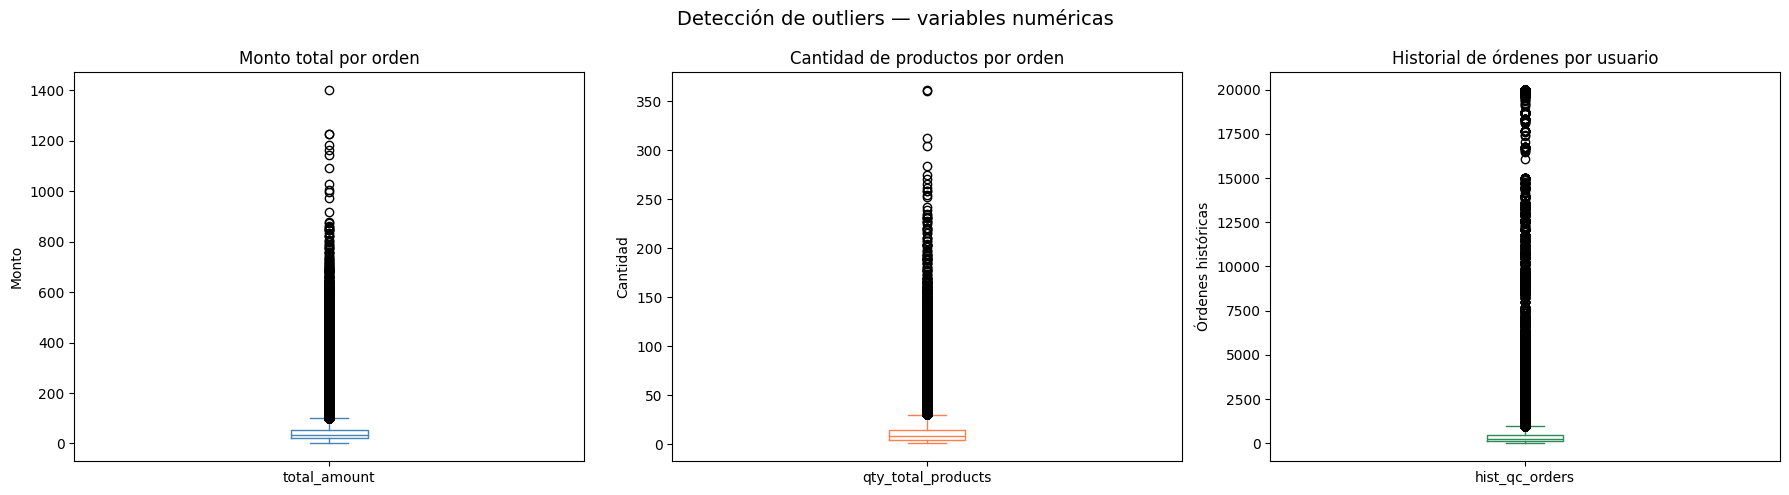

=== OUTLIERS POR MÉTODO IQR ===

total_amount:
  Outliers detectados: 149,591 (6.0%)
  Rango normal: -27.8 a 102.0
  Valor máximo: 1403.3

qty_total_products:
  Outliers detectados: 123,545 (5.0%)
  Rango normal: -10.0 a 30.0
  Valor máximo: 362.0

hist_qc_orders:
  Outliers detectados: 43,589 (6.7%)
  Rango normal: -369.5 a 1002.5
  Valor máximo: 19999.0



In [22]:
# Boxplot de variables cuantitativas

# Boxplots de variables numéricas para detectar outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total amount (sin extremos para visualizar mejor)
df.groupby('order_id')['total_amount'].first().plot(
    kind='box', ax=axes[0], color='steelblue'
)
axes[0].set_title('Monto total por orden')
axes[0].set_ylabel('Monto')

# Cantidad de productos
df.groupby('order_id')['qty_total_products'].first().plot(
    kind='box', ax=axes[1], color='coral'
)
axes[1].set_title('Cantidad de productos por orden')
axes[1].set_ylabel('Cantidad')

# Historial por usuario
df.groupby('user_id')['hist_qc_orders'].first().plot(
    kind='box', ax=axes[2], color='seagreen'
)
axes[2].set_title('Historial de órdenes por usuario')
axes[2].set_ylabel('Órdenes históricas')

plt.suptitle('Detección de outliers — variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

# Cuantificación de outliers con método IQR
print("=== OUTLIERS POR MÉTODO IQR ===\n")
for var, grupo in [
    ('total_amount', df.groupby('order_id')['total_amount'].first()),
    ('qty_total_products', df.groupby('order_id')['qty_total_products'].first()),
    ('hist_qc_orders', df.groupby('user_id')['hist_qc_orders'].first())
]:
    Q1 = grupo.quantile(0.25)
    Q3 = grupo.quantile(0.75)
    IQR = Q3 - Q1
    outliers = grupo[(grupo < Q1 - 1.5*IQR) | (grupo > Q3 + 1.5*IQR)]
    print(f"{var}:")
    print(f"  Outliers detectados: {len(outliers):,} ({len(outliers)/len(grupo)*100:.1f}%)")
    print(f"  Rango normal: {Q1 - 1.5*IQR:.1f} a {Q3 + 1.5*IQR:.1f}")
    print(f"  Valor máximo: {grupo.max():.1f}\n")


In [15]:
# Variable Total_amount: Valores = $0, ¿Estan bien esos datos?

total_ordenes = df['order_id'].nunique()
n_cero = df[df['total_amount'] == 0]['order_id'].nunique()
pct_cero = n_cero / total_ordenes * 100

print(f"Total de órdenes:             {total_ordenes:,}")
print(f"Órdenes con total_amount = 0: {n_cero:,}  ({pct_cero:.2f}%)")

Total de órdenes:             2,474,292
Órdenes con total_amount = 0: 5,112  (0.21%)


In [16]:
# Detalle de las órdenes con monto $0

df[df['total_amount'] == 0].drop_duplicates('order_id')[['has_discount', 'business_type_name', 'qty_total_products']].describe()

,qty_total_products
count,5112.0
mean,9.498044
std,7.500003
min,1.0
25%,4.0
50%,8.0
75%,12.0
max,92.0


In [17]:
# Evaluo de las ordenes que tien total_amount = $0, cuantas tienen descuento

df_cero = df[df['total_amount'] == 0].drop_duplicates('order_id')
vc = df_cero['has_discount'].value_counts()
pct = df_cero['has_discount'].value_counts(normalize=True).mul(100).round(2)
pd.DataFrame({'n': vc, '%': pct})

,n,%
has_discount,,
True,5111,99.98
False,1,0.02


- Las ordenes con monto = 0 tienen descuento. No se eliminan



In [23]:
# Percentil 99 de total_amount y qty_total_products (Para mejorar visualización de graficos)

df_ord = df.drop_duplicates('order_id')

for col in ['total_amount', 'qty_total_products']:
    s = df_ord[col]
    p99 = s.quantile(0.99)
    n_sobre = (s > p99).sum()
    pct = n_sobre / len(s) * 100
    print(f"{col}:")
    print(f"  p99         = {p99:.1f}")
    print(f"  sobre p99   = {n_sobre:,}  ({pct:.2f}%)")
    print(f"  máximo      = {s.max():.1f}")
    print()

total_amount:
  p99         = 187.0
  sobre p99   = 24,743  (1.00%)
  máximo      = 1403.3

qty_total_products:
  p99         = 49.0
  sobre p99   = 24,456  (0.99%)
  máximo      = 362.0



In [24]:
#Evaluo como se comporta total_amount con la cantidad de prodocutos de que tiene la orden
# Top 10 órdenes por total_amount — relación con qty_total_products

p99_qty = df_ord['qty_total_products'].quantile(0.99)

top10 = df_ord.nlargest(10, 'total_amount')[
    ['order_id', 'total_amount', 'qty_total_products', 'business_type_name', 'weekday']
].copy()

top10['precio_unitario'] = (top10['total_amount'] / top10['qty_total_products']).round(2)
top10['qty_sobre_p99']   = top10['qty_total_products'] > p99_qty
top10

,order_id,total_amount,qty_total_products,business_type_name,weekday,precio_unitario,qty_sobre_p99
2424041,cwaZ6h52Pk0jQI+SrrWx4vNu1pNjnmIFHiJUrn+rKPo=,1403.265724,5,Market,Monday,280.65,False
773335,lU0gzaVVEUfwumQ3qehDodnLIQ/bgJqqWSbjNHFQ+ug=,1227.550989,304,Market,Sunday,4.04,True
78998,wcONWLOWNScohPBlQ9TBYlYoIDgxqTDVUSQN4vfwYxw=,1225.920748,262,Market,Wednesday,4.68,True
425403,FZCsCknPoYl0Cza5NysDucShUUIFygAGGywAYRuTtyw=,1182.623469,126,Market,Saturday,9.39,True
65516,HfpbukKI8FbyEZYNuICfdyx6L/qnBpa76GP7oz9B69w=,1162.362889,190,Market,Thursday,6.12,True
79710,GeM9ZgjaQNiFinxZnD0YvVLTvo8iU40072j7JGD03f8=,1143.498362,232,Market,Friday,4.93,True
14792679,jpQ4XPvo+7ak2B5w9TMsgCxJYRmsXmNHJOCgCn741pU=,1091.486201,3,Market,Friday,363.83,False
103176,219eQXAuI8wM6qvnoLjUf7W05fwB/VogDIoPdLBcqyA=,1028.155778,154,Market,Friday,6.68,True
559299,S2Y2IDASsG3IjyAfl2pGkaSW9VsrXh7OpRjEdaS4thU=,1006.150244,203,Market,Sunday,4.96,True
104167,pVZrzSbV0rKrEZ+rkOQCj/zlPsEJJX5d/GAGyaWr0vk=,996.016455,113,Market,Friday,8.81,True


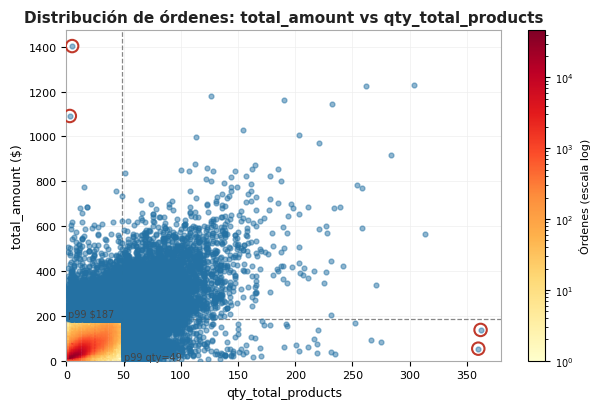

In [27]:
#Realizo grafico total_amount con qty_total_products.  Desde p99 para hacer enfasis en los comportamientos mas altos.

p99_amount = df_ord['total_amount'].quantile(0.99)
p99_qty    = df_ord['qty_total_products'].quantile(0.99)
p50_qty    = df_ord['qty_total_products'].quantile(0.50)

# Masa: dentro del p99 en ambas dimensiones
df_bulk = df_ord[(df_ord['total_amount'] <= p99_amount) & (df_ord['qty_total_products'] <= p99_qty)]

# Extremos: sobre p99 en al menos una dimensión
df_ext = df_ord[(df_ord['total_amount'] > p99_amount) | (df_ord['qty_total_products'] > p99_qty)]

# 4 puntos anómalos
anomalos_precio = df_ord[df_ord['qty_total_products'] < p50_qty].nlargest(2, 'total_amount')
anomalos_qty    = df_ord[df_ord['qty_total_products'] > 350].nsmallest(2, 'total_amount')
anomalos = pd.concat([anomalos_precio, anomalos_qty])

fig, ax = plt.subplots(figsize=(6.3, 4.2), facecolor='white')

hb = ax.hexbin(
    df_bulk['qty_total_products'],
    df_bulk['total_amount'],
    gridsize=50,
    bins='log',
    cmap='YlOrRd',
    mincnt=1,
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label('Órdenes (escala log)', fontsize=8)
cb.ax.tick_params(labelsize=7)

ax.scatter(df_ext['qty_total_products'], df_ext['total_amount'],
           color='#2471A3', s=12, alpha=0.5, zorder=3)

# Círculo rojo hueco sobre los 4 anómalos
ax.scatter(anomalos['qty_total_products'], anomalos['total_amount'],
           facecolors='none', edgecolors='#C0392B', linewidths=1.5, s=80, zorder=6)

ax.axvline(p99_qty,    color='#555555', linewidth=0.9, linestyle='--', alpha=0.7)
ax.axhline(p99_amount, color='#555555', linewidth=0.9, linestyle='--', alpha=0.7)
ax.text(p99_qty + 1,  5, f'p99 qty={p99_qty:.0f}',  fontsize=7, color='#444444')
ax.text(1, p99_amount + 8, f'p99 ${p99_amount:.0f}', fontsize=7, color='#444444')

ax.set_xlim(0, df_ord['qty_total_products'].max() * 1.05)
ax.set_ylim(0, df_ord['total_amount'].max() * 1.05)
ax.set_xlabel('qty_total_products', fontsize=9)
ax.set_ylabel('total_amount ($)', fontsize=9)
ax.set_title('Distribución de órdenes: total_amount vs qty_total_products',
             fontsize=11, fontweight='bold', color='#222222')

for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontsize(8)

ax.set_facecolor('white')
ax.grid(color='#EEEEEE', linewidth=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor('#AAAAAA')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('hexbin_amount_qty.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

- Hay dos precios muy altos con pocas cantidades de productos
- Hay dos cantidades de productos con precios totales muy bajos

In [28]:
#Los 4 valores anomalos detectados, ¿presentan algo en común?

anomalos[['order_id', 'total_amount', 'qty_total_products', 'partner_id', 'business_type_name', 'weekday']].reset_index(drop=True)

,order_id,total_amount,qty_total_products,partner_id,business_type_name,weekday
0,cwaZ6h52Pk0jQI+SrrWx4vNu1pNjnmIFHiJUrn+rKPo=,1403.265724,5,3FZ54oF+BbQGLLsbF8IlWrmLdzVQfGjLkl0SKQOZVHs=,Market,Monday
1,jpQ4XPvo+7ak2B5w9TMsgCxJYRmsXmNHJOCgCn741pU=,1091.486201,3,DC1oy6UfHZM7Q+sRm6WtqtmCKlTkPRmhQtzcU7kjJwM=,Market,Friday
2,ARwsGKIV/fz+TxMgA7nOc3fVIKn0060l8kPkmdDiIxk=,53.764470,360,DY21VjghiJRyXaCYDaryx3Zupn8KhNEcMHAMmRaI7X4=,Market,Friday
3,1Qnzv0AV2HpmrRywbKcE16kvwA8Hj5k2pAyRBhyen3o=,137.323400,362,l6GZws9fvPJkZtUmXgYnmIplDSpZzx7TCYGWkS8ITkY=,Market,Friday


In [ ]:
# hist_qc_orders = 19,999 — posible valor de tope artificial?

s = df.drop_duplicates('order_id')['hist_qc_orders']

p99  = s.quantile(0.99)
p999 = s.quantile(0.999)

df_cap = df[df['hist_qc_orders'] == 19999].drop_duplicates('order_id')
print(f"p99               = {p99:,.0f}")
print(f"p99.9             = {p999:,.0f}")
print(f"máximo            = {s.max():,.0f}")
print()
print(f"Órdenes con hist_qc_orders = 19,999: {len(df_cap):,}  ({len(df_cap)/s.count()*100:.3f}%)")
print(f"Usuarios únicos con ese valor:        {df[df['hist_qc_orders'] == 19999]['user_id'].nunique():,}")

In [29]:
# Variables categoricas: category — revisión de los 62 valores únicos para detectar inconsistencias en valores

cat_counts = df['category'].value_counts().reset_index()
cat_counts.columns = ['category', 'n']
cat_counts['%'] = (cat_counts['n'] / len(df) * 100).round(2)
pd.set_option('display.max_rows', 70)
cat_counts

,category,n,%
0,pagnificados,1177330,7.57
1,verduras,1168870,7.52
2,snacks,919801,5.91
3,lacteos,860789,5.54
4,quesos,843570,5.42
5,bebidas,739502,4.76
6,cuidado personal,659808,4.24
7,general,583489,3.75
8,condimentos especias,579854,3.73
9,frutas,577002,3.71


In [30]:
#La categoria que no tiene valores, como se comporta?

n_vacias   = (df['category'] == '').sum()
n_espacios = df['category'].str.strip().eq('').sum()
total      = len(df)

print(f"Registros con category vacía (''): {n_vacias:,}  ({n_vacias/total*100:.2f}%)")
print(f"Registros con category solo espacios: {n_espacios:,}  ({n_espacios/total*100:.2f}%)")

Registros con category vacía (''): 14,679  (0.09%)
Registros con category solo espacios: 14,679  (0.09%)


In [ ]:
# Correcciones de nomenclatura en category (Sin datos y lacteos)

# 1. 'dairy' es equivalente a 'lacteos' — unificación de idioma
n_dairy = (df['category'] == 'dairy').sum()
df['category'] = df['category'].replace('dairy', 'lacteos')

# 2. Categoría vacía → 'Sin categoría'
n_vacias = (df['category'] == '').sum()
df['category'] = df['category'].replace('', 'Sin categoría')

print(f"Registros reclasificados 'dairy'  'lacteos':       {n_dairy:,}")
print(f"Registros reclasificados '' → 'Sin categoría':      {n_vacias:,}")
print(f"Categorías únicas tras correcciones: {df['category'].nunique()}")

In [31]:
# Cobertura temporal: verificar que hour y weekday tienen representación completa

df_ord = df.drop_duplicates('order_id')

# -- hour: esperados 0–23 --
horas_presentes = sorted(df_ord['hour'].dropna().unique())
horas_faltantes = [h for h in range(24) if h not in horas_presentes]

print(" hour ")
print(f"Horas distintas cubiertas: {len(horas_presentes)} / 24")
print(f"Horas sin datos:           {horas_faltantes if horas_faltantes else 'ninguna'}")
print()

# Órdenes por hora
conteo_hora = df_ord['hour'].value_counts().sort_index()
min_h, max_h = conteo_hora.min(), conteo_hora.max()
print(f"Hora con menos órdenes: {conteo_hora.idxmin()}h  ({min_h:,} órdenes)")
print(f"Hora con más órdenes:   {conteo_hora.idxmax()}h  ({max_h:,} órdenes)")
print(f"Ratio max/min:          {max_h/min_h:.1f}x")
print()

# -- weekday: esperados 7 días --
dias_presentes = sorted(df_ord['weekday'].dropna().unique())
dias_faltantes = [d for d in ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
                  if d not in dias_presentes]

print(" weekday ")
print(f"Días distintos cubiertos: {len(dias_presentes)} / 7")
print(f"Días sin datos:           {dias_faltantes if dias_faltantes else 'ninguno'}")
print()

conteo_dia = df_ord['weekday'].value_counts()
min_d, max_d = conteo_dia.min(), conteo_dia.max()
print(f"Día con menos órdenes: {conteo_dia.idxmin()}  ({min_d:,} órdenes)")
print(f"Día con más órdenes:   {conteo_dia.idxmax()}  ({max_d:,} órdenes)")
print(f"Ratio max/min:         {max_d/min_d:.1f}x")

 hour 
Horas distintas cubiertas: 24 / 24
Horas sin datos:           ninguna

Hora con menos órdenes: 4h  (120 órdenes)
Hora con más órdenes:   19h  (276,877 órdenes)
Ratio max/min:          2307.3x

 weekday 
Días distintos cubiertos: 7 / 7
Días sin datos:           ninguno

Día con menos órdenes: Wednesday  (300,678 órdenes)
Día con más órdenes:   Sunday  (445,434 órdenes)
Ratio max/min:         1.5x


## **03. Agrupación por order_id**

In [33]:
# Agrupación por orden

orden_cols = ["weekday", "hour", "business_type_name", "partner_id", "user_id",
              "qty_total_products", "total_amount", "has_discount", "is_food", "hist_qc_orders"]

df_orders = (
    df.groupby("order_id", sort=False)
    .agg(**{col: (col, "first") for col in orden_cols})
    .reset_index()
)

print(f"Filas en df (producto-orden): {len(df):,}")
print(f"Órdenes únicas en df_orders:  {len(df_orders):,}")
df_orders.head()

Filas en df (producto-orden): 15,551,102
Órdenes únicas en df_orders:  2,474,292


,order_id,weekday,hour,business_type_name,partner_id,user_id,qty_total_products,total_amount,has_discount,is_food,hist_qc_orders
0,PpTjCz6Rpezd61n5dPDJTuRqdeuei9ZF179usLRlHDo=,Wednesday,2,Kiosks,wGj5g/FyaoIGakOjc8rsSMKLP4ObLso+ToeBLz5gYXA=,MK8B+8oYcJV/UOWHXwSRZKONfUd4BeOoYDlqDfsf6G8=,4,29.047982,True,True,3857
1,b2fkJT7l609B1C5C4mOPpEGmJN9kFsFBEMfA1CFcg+Q=,Wednesday,6,Market,boCBw+WzpRefsURSsXYnYGpr1HAK4RBUHV8hCmvGxGE=,xL2+iPNakXvX1le6s/sXR6QoP2FF44ZYziBWF9wvUNU=,32,185.701304,True,True,871
2,aRM17cbzgUQM2gYrzeKgZF5iPWe+4BoxGZzUR4I9u9M=,Friday,7,Market,CSq+DtmiVKcNLprPiiWNTgH5sg97DimLHyswaz3tA5M=,Tk6M9oGhf9s7nUS0Lgf/cYArZLjpsFUnbQzFsQJB2Fc=,39,161.954034,True,True,198
3,ofBqN0N2C1oa7TclCSCS5PTJKTF4DWZJUA85gymH2rY=,Friday,7,Market,CSq+DtmiVKcNLprPiiWNTgH5sg97DimLHyswaz3tA5M=,SJ9SEqbIILAEiKPrZ1+18MvW76IDBljdaYCT18wSjWA=,11,32.065813,True,True,246
4,0/7FYlHaqnXz2vaadJWARDRCjxDNRTgguABQXg/mlXc=,Friday,7,Market,T4q47JhNP6vNeE2q/TgmqAJ+QQ1ryCWfr+virSVP8JA=,gI3OKl4ZOAL9N6+RsNfSxwx0oW4Ho3W3jO/KMt9pkqE=,11,25.598921,True,True,233


In [32]:
# Verificar que todas las columnas de orden son constantes dentro de cada order_id

order_cols = ['weekday', 'hour', 'business_type_name', 'partner_id', 'user_id',
              'qty_total_products', 'total_amount', 'has_discount', 'is_food', 'hist_qc_orders']

for col in order_cols:
    n_varies = (df.groupby('order_id')[col].nunique() > 1).sum()
    print(f"{col:25s}: {n_varies:,} órdenes con más de un valor")

weekday                  : 0 órdenes con más de un valor
hour                     : 0 órdenes con más de un valor
business_type_name       : 0 órdenes con más de un valor
partner_id               : 0 órdenes con más de un valor
user_id                  : 0 órdenes con más de un valor
qty_total_products       : 0 órdenes con más de un valor
total_amount             : 0 órdenes con más de un valor
has_discount             : 0 órdenes con más de un valor
is_food                  : 0 órdenes con más de un valor
hist_qc_orders           : 0 órdenes con más de un valor


## **04.  Analisis Univariado**

## *Resumen*
|Tarea|Utilidad|Estado|
|---|---|---|

## **05.  Analisis Bivariado**